In [1]:
import os
import numpy as np
import pandas as pd
import sys
import json
import networkx as nx
import matplotlib.pyplot as plt
import math
from glob import glob
import os.path as op

# Add rpy2
%load_ext rpy2.ipython

Error importing in API mode: ImportError("dlopen(/Users/abry4213/miniforge3/envs/annie_env/lib/python3.10/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <2EEBEE81-EBFD-3117-97B1-20AFEEB66792> /Users/abry4213/miniforge3/envs/annie_env/lib/python3.10/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


In [2]:
%%R 

suppressPackageStartupMessages({
    library(broom)
    library(cowplot)
    library(ggsegSchaefer)
    library(ggseg)
    library(tidyverse)
})


# Set cowplot theme
theme_set(theme_cowplot())

In [10]:
%%R

library(ggseg)
library(dplyr)

regions_to_highlight <- tibble(
  region = c(
    "7Networks_RH_Vis_3",
    "7Networks_LH_DorsAttn_Post_1"
  ),
  highlight = "yes"
)

regions_to_highlight %>% 
    left_join(., schaefer7_100 %>% as_tibble()) %>%
    dplyr::select(-label) %>% 
    head()

Joining with `by = join_by(region)`
# A tibble: 3 × 8
  region       highlight atlas type  hemi  side  roi                    geometry
  <chr>        <chr>     <chr> <chr> <chr> <chr> <chr>            <MULTIPOLYGON>
1 7Networks_R… yes       Scha… cort… right late… 0004  (((1124.739 94.17141, 11…
2 7Networks_L… yes       Scha… cort… left  late… 0017  (((233.3118 76.25215, 22…
3 7Networks_L… yes       Scha… cort… left  medi… 0017  (((441.4356 27.50478, 47…


merging atlas and data by 'region', 'atlas', 'type', 'hemi', 'side', 'geometry'


merging atlas and data by 'region'


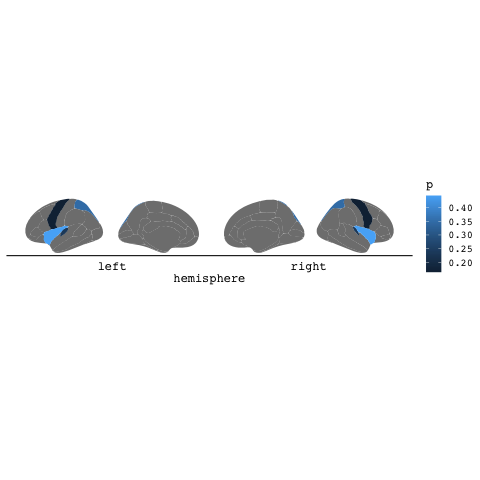

In [15]:
%%R

library(ggseg)
library(dplyr)

some_data <- data.frame(
  region = c(
    "transverse temporal",
    "insula",
    "precentral",
    "superior parietal"
  ),
  p = sample(seq(0, .5, .001), 4),
  stringsAsFactors = FALSE
)

ggseg(.data = some_data, mapping = aes(fill = p))

merging atlas and data by 'region'


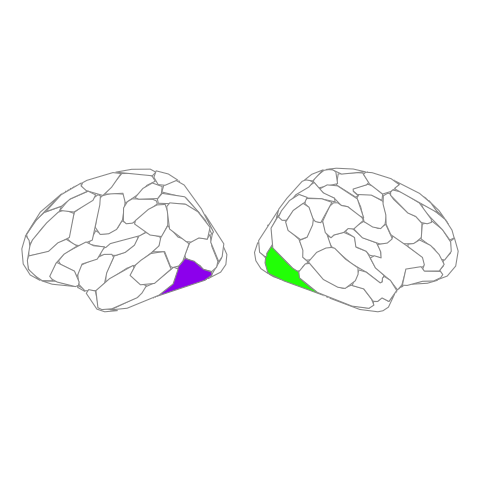

In [25]:
%%R

library(ggseg)
library(dplyr)

some_data <- data.frame(
  region = c(
    "7Networks_RH_Vis_3",
    "7Networks_LH_DorsAttn_Post_1"
  ),
  p = c("1","2"),
  stringsAsFactors = FALSE
)

ggseg(.data = some_data, mapping = aes(fill = p), atlas=schaefer7_100, view = "lateral", color='gray60') +
  theme_void() +
  scale_fill_manual(values=c("1" = "green", "2" = "purple"), na.value='white') +
  theme(legend.position='none')

# ggsave('plots/methods/Schaefer_CS_regions.svg', width=4, height=3, units='in', dpi=300)